# PART 1: EDA

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Flowers102


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Flowers102


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision import datasets, transforms
from torch.utils.data import Dataset,DataLoader, Subset
from collections import Counter
import pandas as pd
import seaborn as sns
from PIL import Image
import scipy.io
from typing import List, Tuple, Optional, Union, Dict

import os
import warnings

flower_names = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea", "english marigold",
    "tiger lily", "moon orchid", "bird of paradise", "monkshood", "globe thistle",
    "snapdragon", "colt's foot", "king protea", "spear thistle", "yellow iris",
    "globe-flower", "purple coneflower", "peruvian lily", "balloon flower", "giant white arum lily",
    "fire lily", "pincushion flower", "fritillary", "red ginger", "grape hyacinth",
    "corn poppy", "prince of wales feathers", "stemless gentian", "artichoke", "sweet william",
    "carnation", "garden phlox", "love in the mist", "mexican aster", "alpine sea holly",
    "ruby-lipped cattleya", "cape flower", "great masterwort", "siam tulip", "lenten rose",
    "barbeton daisy", "daffodil", "sword lily", "poinsettia", "ステマ (bolero deep blue)",
    "wallflower", "marigold", "buttercup", "oxeye daisy", "common dandelion",
    "mexican petunia", "wild pansy", "primula", "sunflower", "pelargonium",
    "bishop of llandaff", "gaura", "geranium", "orange dahlia", "pink-yellow dahlia",
    "cautleya spicata", "japanese anemone", "black-eyed susan", "silverbush", "californian poppy",
    "osteospermum", "spring crocus", "bearded iris", "windflower", "tree poppy",
    "gazania", "azalea", "water lily", "rose", "thorn apple",
    "morning glory", "passion flower", "lotus", "toad lily", "anthurium",
    "frangipani", "clematis", "hibiscus", "columbine", "desert-rose",
    "tree mallow", "magnolia", "cyclamen", "watercress", "canna lily",
    "hippeastrum", "bee balm", "ball moss", "foxglove", "bougainvillea",
    "camellia", "mallow", "mexican creaster", "bromelia", "blanket flower",
    "trumpet creeper", "blackberry lily"
]

class_labels="/content/drive/MyDrive/Flowers102/data/flowers-102/imagelabels.mat"

# Load [Datasets](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Flowers102.html#torchvision.datasets.Flowers102)

In [3]:
raw_set = datasets.Flowers102(root='data', split='test', download=True)
raw_test_set= datasets.Flowers102(root='data', split='train', download=True)
raw_val_set = datasets.Flowers102(root='data', split='val', download=True)


I noticed that the split argument for test and train is switched. the train set have only 10 images in each class while the test set have an unbalanced image for each class. So I switch their annotate that the `train_set` have `split=test` while `test_set` have `split=train`

# EDA: Class Distribution

--- Starting Dataset Audit (N=6149) ---


/tmp/ipython-input-3560088444.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dist, x='Class', y='Count', palette='viridis')


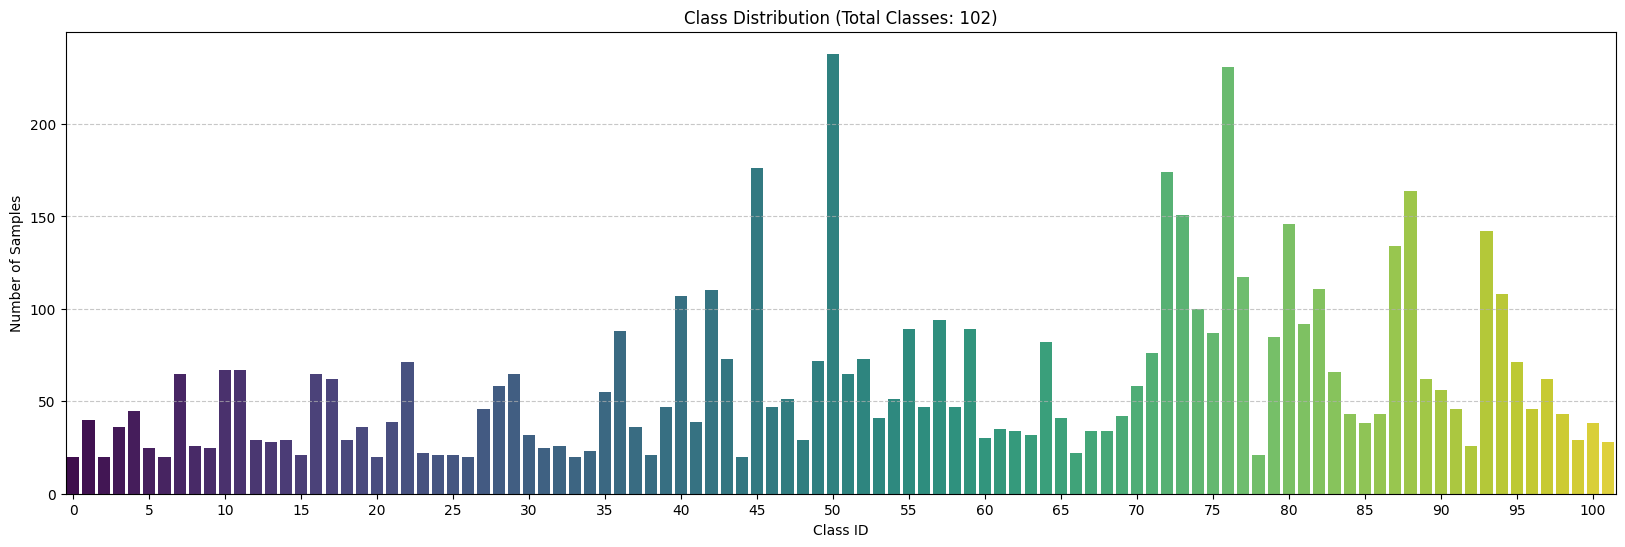

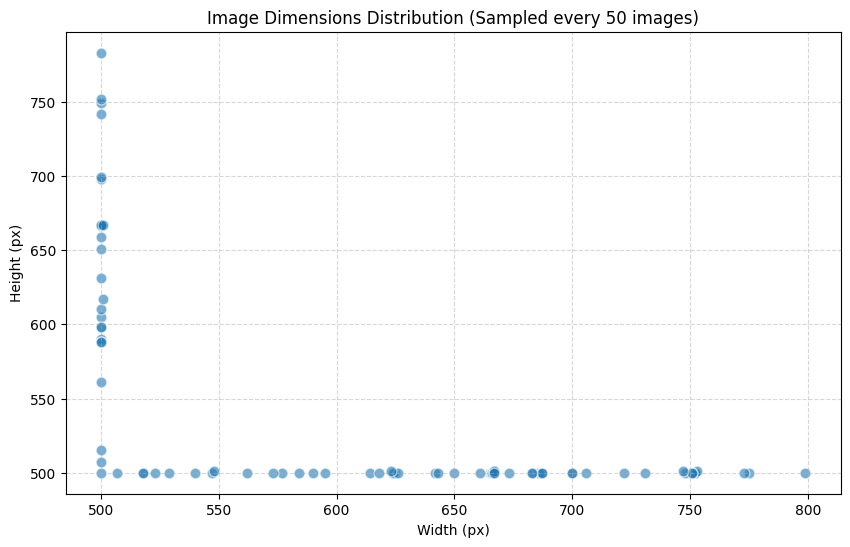

--- Audit Completed ---


In [4]:


def get_dataset_labels(dataset: Dataset) -> List[int]:
    """
    Safely retrieves labels from a dataset.
    Tries accessing private attributes first for speed, falls back to iteration.
    """
    # 1. Try accessing standard private attributes for speed (common in torchvision)
    if hasattr(dataset, '_labels'): # Flowers102
        return dataset._labels
    elif hasattr(dataset, 'targets'): # MNIST/CIFAR
        return dataset.targets
    elif hasattr(dataset, 'labels'):
        return dataset.labels

    # 2. Fallback: Iterate (Slower, but works for any Dataset)
    warnings.warn("Direct label access failed. Iterating dataset to count labels (this may take time)...")
    return [label for _, label in dataset]

def plot_class_distribution(labels: List[int]) -> None:
    """
    Plots the bar chart of class distribution.
    """
    counts = Counter(labels)
    df_dist = pd.DataFrame({'Class': list(counts.keys()), 'Count': list(counts.values())})

    plt.figure(figsize=(20, 6))
    sns.barplot(data=df_dist, x='Class', y='Count', palette='viridis')
    plt.title(f"Class Distribution (Total Classes: {len(counts)})")
    plt.xlabel("Class ID")
    plt.ylabel("Number of Samples")

    # Clean up x-ticks for readability
    if len(counts) > 50:
        plt.xticks(range(0, max(counts.keys()) + 1, 5))

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def plot_image_dimensions(dataset: Dataset, sample_step: int = 50) -> None:
    """
    Plots a scatter plot of image dimensions (Width vs Height).
    Uses sampling to maintain performance.

    Args:
        dataset (Dataset): The dataset to analyze.
        sample_step (int): The interval for sampling images (higher = faster).
    """
    dims: List[Tuple[int, int]] = []

    # Iterate with step to save time
    for i in range(0, len(dataset), sample_step):
        try:
            img, _ = dataset[i]
            # Handle both PIL Images and Tensors
            if hasattr(img, 'size'):
                dims.append(img.size) # PIL: (width, height)
            elif hasattr(img, 'shape'):
                # Tensor: (C, H, W) -> need (W, H)
                dims.append((img.shape[2], img.shape[1]))
        except Exception as e:
            continue

    if not dims:
        print("Could not extract dimensions. Check dataset format.")
        return

    widths, heights = zip(*dims)

    plt.figure(figsize=(10, 6))
    plt.scatter(widths, heights, alpha=0.6, edgecolors='w', s=60)
    plt.title(f"Image Dimensions Distribution (Sampled every {sample_step} images)")
    plt.xlabel("Width (px)")
    plt.ylabel("Height (px)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def analyze_dataset_quality(dataset: Dataset, sample_step: int = 50) -> None:
    """
    Main function to run the dataset quality audit.

    Args:
        dataset (Dataset): The PyTorch dataset to audit.
        sample_step (int): Sampling rate for dimension analysis.
    """
    print(f"--- Starting Dataset Audit (N={len(dataset)}) ---")

    # 1. Analyze Class Distribution
    try:
        labels = get_dataset_labels(dataset)
        plot_class_distribution(labels)
    except Exception as e:
        print(f"Skipping class distribution: {str(e)}")

    # 2. Analyze Image Dimensions
    try:
        plot_image_dimensions(dataset, sample_step)
    except Exception as e:
        print(f"Skipping dimension analysis: {str(e)}")

    print("--- Audit Completed ---")

analyze_dataset_quality(raw_set)

The data distribution seems to be uneven. I will use Weighted Random Sampler in Part 2 to ensure the model doesn't ignore underrepresented species.



In [5]:
def load_mat_labels(mat_file_path: str) -> np.ndarray:
    """
    Loads the label array from the Oxford 102 .mat file.

    Args:
        mat_file_path (str): Path to 'imagelabels.mat'.

    Returns:
        np.ndarray: Array of integers representing class IDs (1-102).
    """
    if not os.path.exists(mat_file_path):
        raise FileNotFoundError(f"Label file not found at: {mat_file_path}")

    mat_data = scipy.io.loadmat(mat_file_path)
    # Extract the 'labels' key and flatten it to a 1D array
    labels = mat_data['labels'][0]
    print(f"✅ Loaded {len(labels)} labels from .mat file.")
    return labels

def get_image_path(root_dir: str, image_index: int) -> str:
    """
    Constructs the correct filename for Oxford 102 images based on index.
    Assumes naming convention 'image_00001.jpg' (1-based indexing).

    Args:
        root_dir (str): Folder containing the .jpg files.
        image_index (int): The 0-based index from your dataset wrapper.

    Returns:
        str: Full path to the image file.
    """
    # Oxford 102 files are named image_00001.jpg, so we add 1 to the 0-based index
    file_name = f"image_{image_index + 1:05d}.jpg"
    return os.path.join(root_dir, file_name)

def visualize_single_sample(
    image_index: int,
    labels: np.ndarray,
    flower_names: Union[List[str], Dict[str, str]],
    images_dir: str
) -> None:
    """
    Displays an image with its ground truth label name.

    Args:
        image_index (int): The 0-based index of the image to show.
        labels (np.ndarray): The array of labels.
        flower_names (list or dict): Mapping from ID to Species Name.
        images_dir (str): Directory where images are stored.
    """
    # 1. Get the Label ID (The .mat file uses 1-102)
    label_id = labels[image_index]

    # 2. Get the Species Name
    # Handle if flower_names is a List (0-indexed) or Dict (String keys)
    if isinstance(flower_names, list):
        species_name = flower_names[label_id - 1]
    elif isinstance(flower_names, dict):
        species_name = flower_names.get(str(label_id), "Unknown")
    else:
        species_name = f"Class {label_id}"

    # 3. Load Image
    img_path = get_image_path(images_dir, image_index)

    if not os.path.exists(img_path):
        print(f"❌ Error: Image file not found: {img_path}")
        return

    img = mpimg.imread(img_path)

    # 4. Plot
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"ID: {image_index} | Label: {label_id}\nSpecies: {species_name}")
    plt.axis('off')
    plt.show()

✅ Loaded 8189 labels from .mat file.


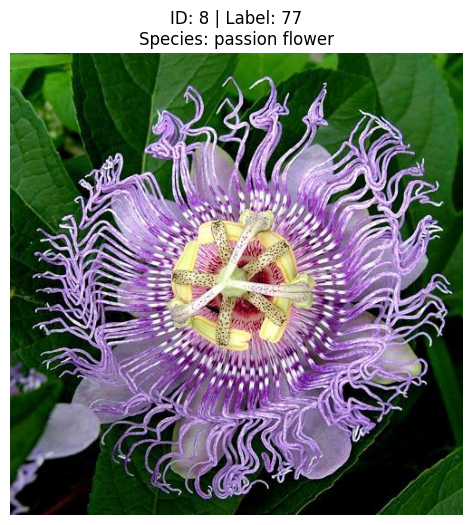

In [6]:
IMG_DIR = "/content/drive/MyDrive/Flowers102/img/"

labels = load_mat_labels(class_labels)

# This will now safely show the CORRECT image for index 8
visualize_single_sample(8, labels, flower_names, IMG_DIR)